# Weighted VC Update Analysis (May 2026)
Comprehensive analysis of the `WeightedVCRepairer` experiments involving Alpha and Epsilon sweeps.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Load aggregated data
df = pd.read_csv('../experiments_weighted_may2026.csv')

# Pre-processing
df['alpha'] = df['meta_repairer_params_alpha']
df['epsilon'] = df['experiment_name'].str.extract('eps([0-9.]+)').astype(float).fillna(1.0) # Assume eps=1.0 for standard models if not specified
df['engine'] = df['meta_synthesizer_params_model_path'].apply(lambda x: 'aim' if 'aim' in str(x) else ('mst' if 'mst' in str(x) else 'unknown'))

print(f"Total records: {len(df)}")
print("Records by Dataset:", df.groupby('dataset').size().to_dict())
print("Records by Engine:", df.groupby('engine').size().to_dict())
print("Unique Epsilon values:", df['epsilon'].unique())

Total records: 188
Records by Dataset: {'adult': 40, 'census': 42, 'compas': 42, 'tax': 64}
Records by Engine: {'aim': 94, 'mst': 94}
Unique Epsilon values: [1.    0.001 0.1   0.2   0.3   0.4   0.5   0.6   0.7   0.8   0.9  ]


In [28]:
df

,dataset,experiment_name,experiment_id,timestamp,meta_loader,meta_synthesizer,meta_obtainer,meta_repairer,meta_synthesizer_params_model_path,meta_synthesizer_params_size,...,violations_synthetic,violations_repaired,loss_function_synthetic_total,loss_function_synthetic_size_component,loss_function_synthetic_marginal_component,loss_function_repaired_total,loss_function_repaired_size_component,loss_function_repaired_marginal_component,alpha,epsilon
0,adult,weighted_updated_alpha_v4_adult_aim_a0.0,c2bc3902,2026-05-15T05:45:06.995114,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim.pkl,50000,...,27382463,0,0.008695,0.0,0.008695,0.012368,0.99802,0.012368,0.00,1.0
1,adult,weighted_updated_alpha_v4_adult_aim_a0.05,bffad687,2026-05-14T18:25:03.236159,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim.pkl,50000,...,27382463,0,0.008260,0.0,0.008695,0.056991,0.86156,0.014645,0.05,1.0
2,adult,weighted_updated_alpha_v4_adult_aim_a0.1,c502ad3a,2026-05-15T00:38:25.330209,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim.pkl,50000,...,27382463,0,0.007826,0.0,0.008695,0.095273,0.86156,0.010130,0.10,1.0
3,adult,weighted_updated_alpha_v4_adult_aim_a0.15,7424e741,2026-05-15T06:28:22.173860,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim.pkl,50000,...,27382463,0,0.007391,0.0,0.008695,0.137728,0.86156,0.009993,0.15,1.0
4,adult,weighted_updated_alpha_v4_adult_aim_a0.25,e131361e,2026-05-14T18:23:35.331428,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim.pkl,50000,...,27382463,0,0.006521,0.0,0.008695,0.228619,0.84176,0.024239,0.25,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,tax,weighted_updated_eps_v4_tax_mst_eps0.6_a0.5,916f7b4d,2026-05-14T17:35:06.203544,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/tax_mst_eps0.6.pkl,50000,...,6136031,0,0.032811,0.0,0.065622,0.606518,0.93660,0.276437,0.50,0.6
184,tax,weighted_updated_eps_v4_tax_mst_eps0.7_a0.5,14d2bde1,2026-05-14T17:35:18.489436,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/tax_mst_eps0.7.pkl,50000,...,6136843,0,0.032659,0.0,0.065318,0.605725,0.93822,0.273231,0.50,0.7
185,tax,weighted_updated_eps_v4_tax_mst_eps0.8_a0.5,84313b22,2026-05-14T23:34:45.454142,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/tax_mst_eps0.8.pkl,50000,...,6113531,0,0.032366,0.0,0.064732,0.601366,0.93062,0.272112,0.50,0.8
186,tax,weighted_updated_eps_v4_tax_mst_eps0.9_a0.5,47d25576,2026-05-14T23:22:16.127003,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/tax_mst_eps0.9.pkl,50000,...,6088515,0,0.033058,0.0,0.066115,0.605081,0.92072,0.289442,0.50,0.9


## Measurement Definitions

In [24]:
metrics = {
    'deletion_ratio_ratio': 'Deletion Ratio',
    'marginals_error_repaired_avg': 'Marginal Error (Repaired)',
    'tvd_2way_repaired_avg': 'TVD 2-way (Repaired)',
    'runtime_repairing': 'Repair Runtime (s)',
    'loss_function_repaired_total': 'Total Loss (Repaired)',
    'loss_function_repaired_marginal_component': 'Marginal Loss (Repaired)',
    'ml_accuracy_repaired_logistic_regression': 'ML Accuracy (LogReg)',
    'ml_accuracy_repaired_random_forest': 'ML Accuracy (RF)',
    'ml_accuracy_repaired_mlp': 'ML Accuracy (MLP)',
    
}

## 1. Alpha Sweep Analysis
Impact of the `alpha` parameter. Note: Epsilon is also shown where available.

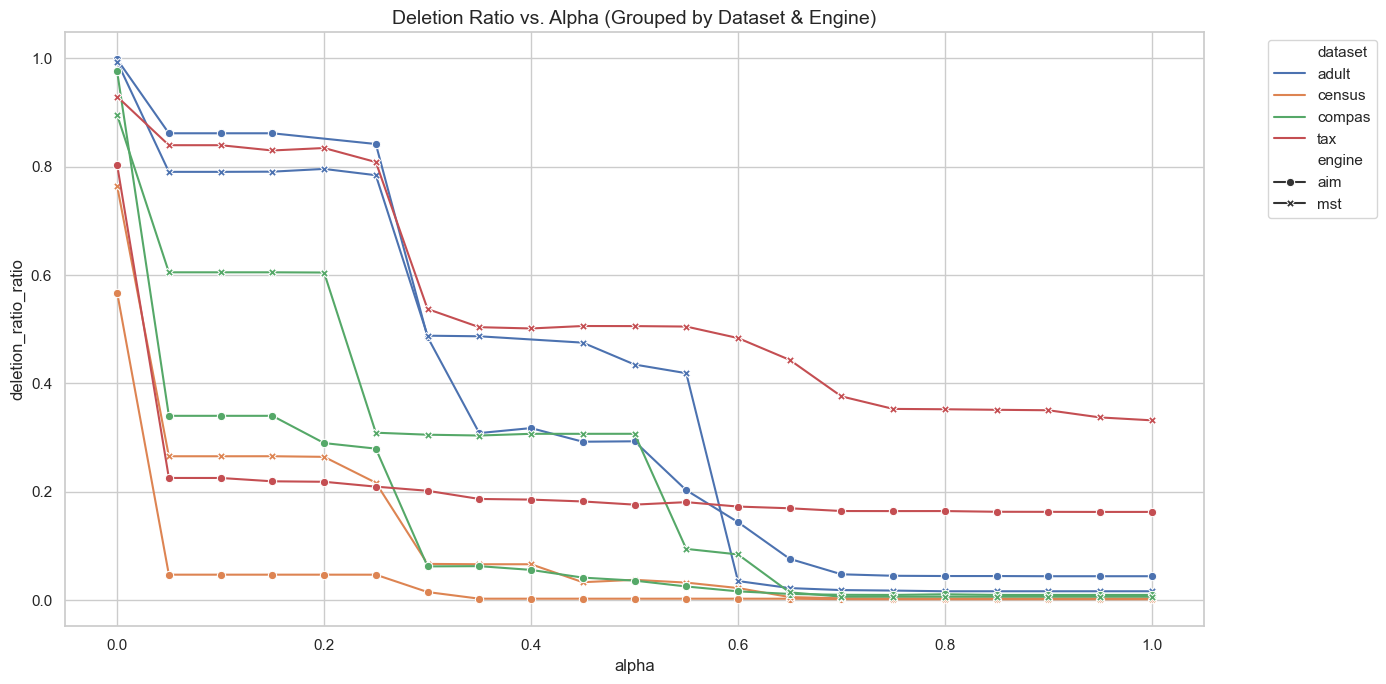

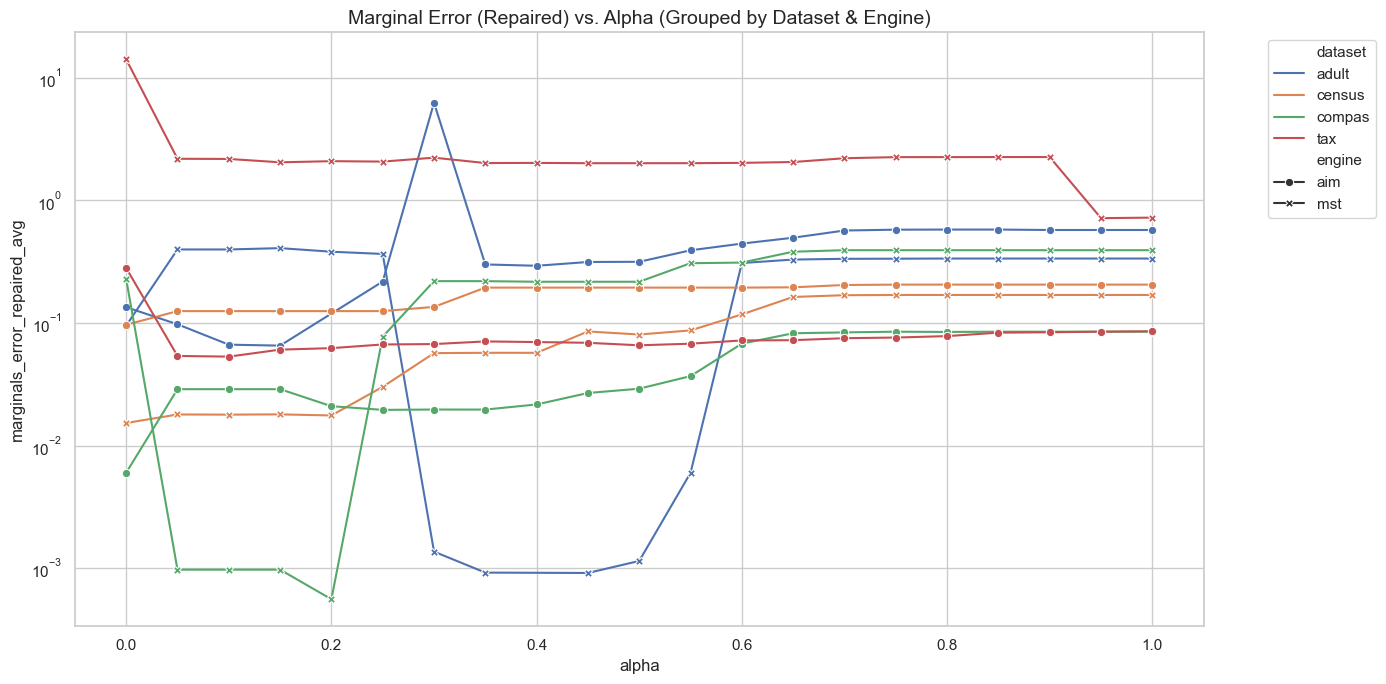

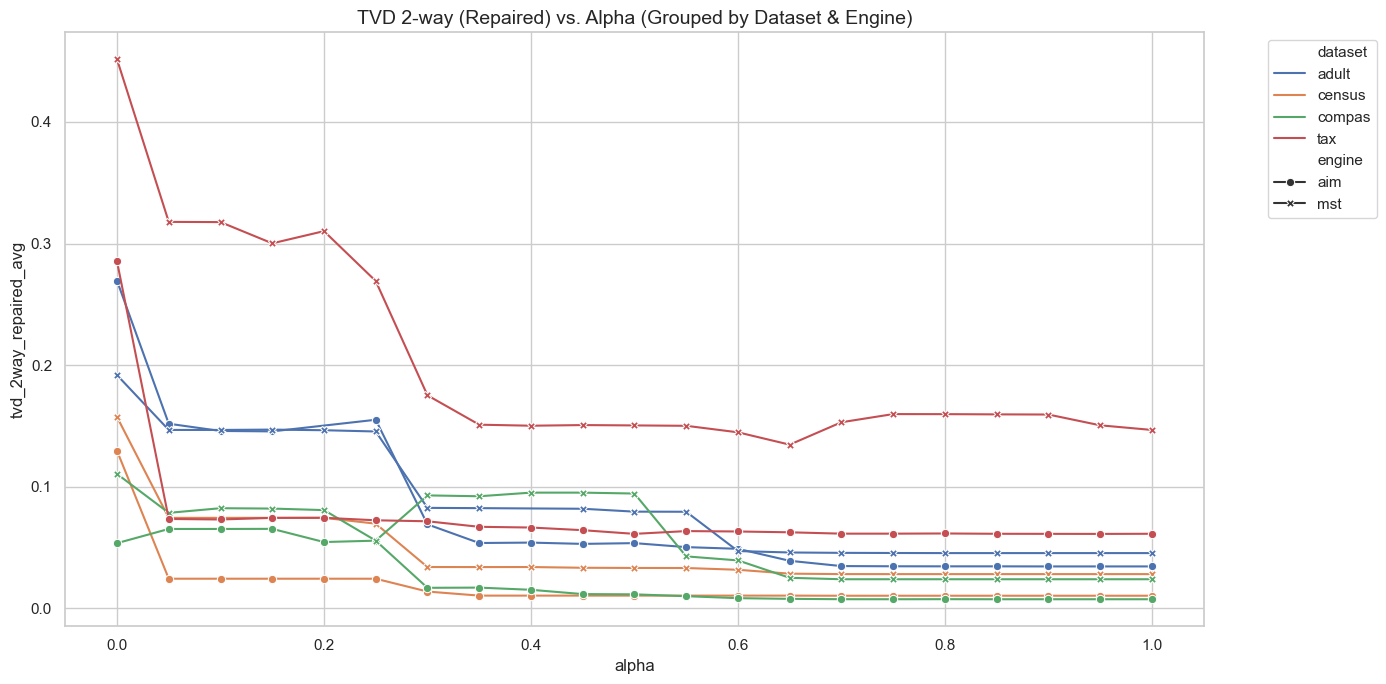

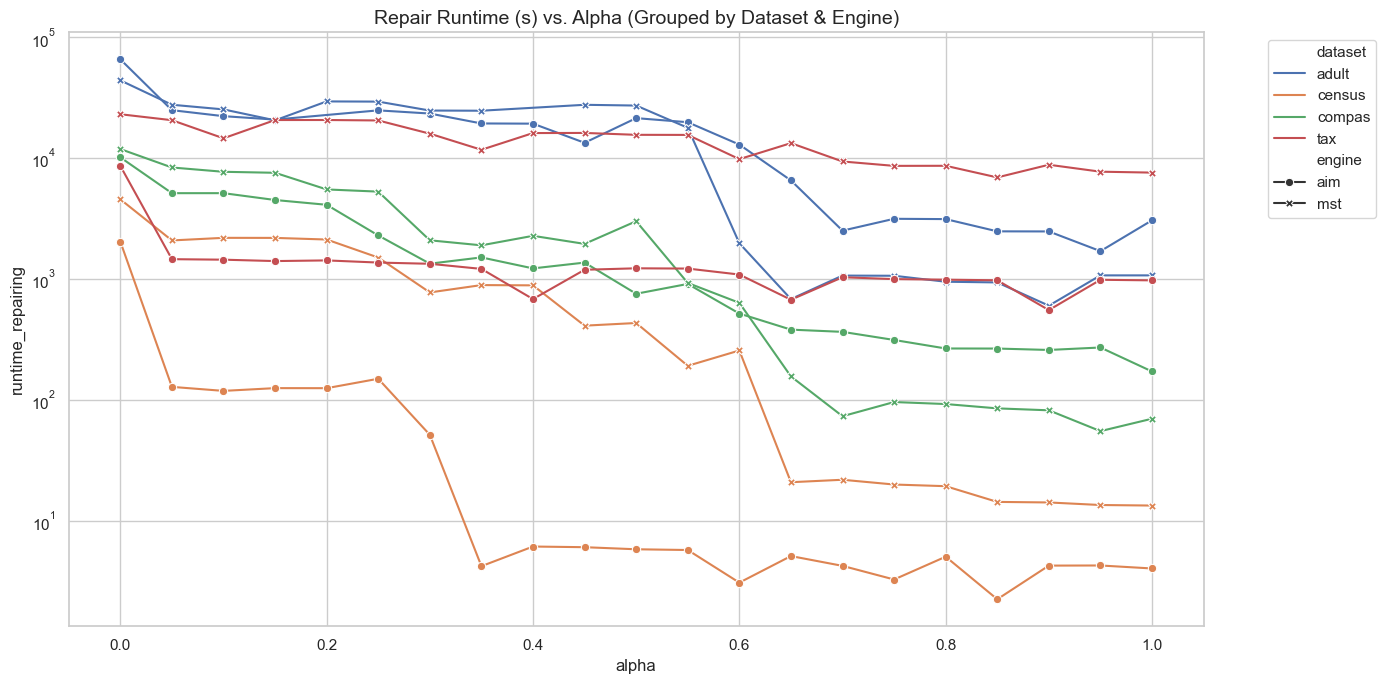

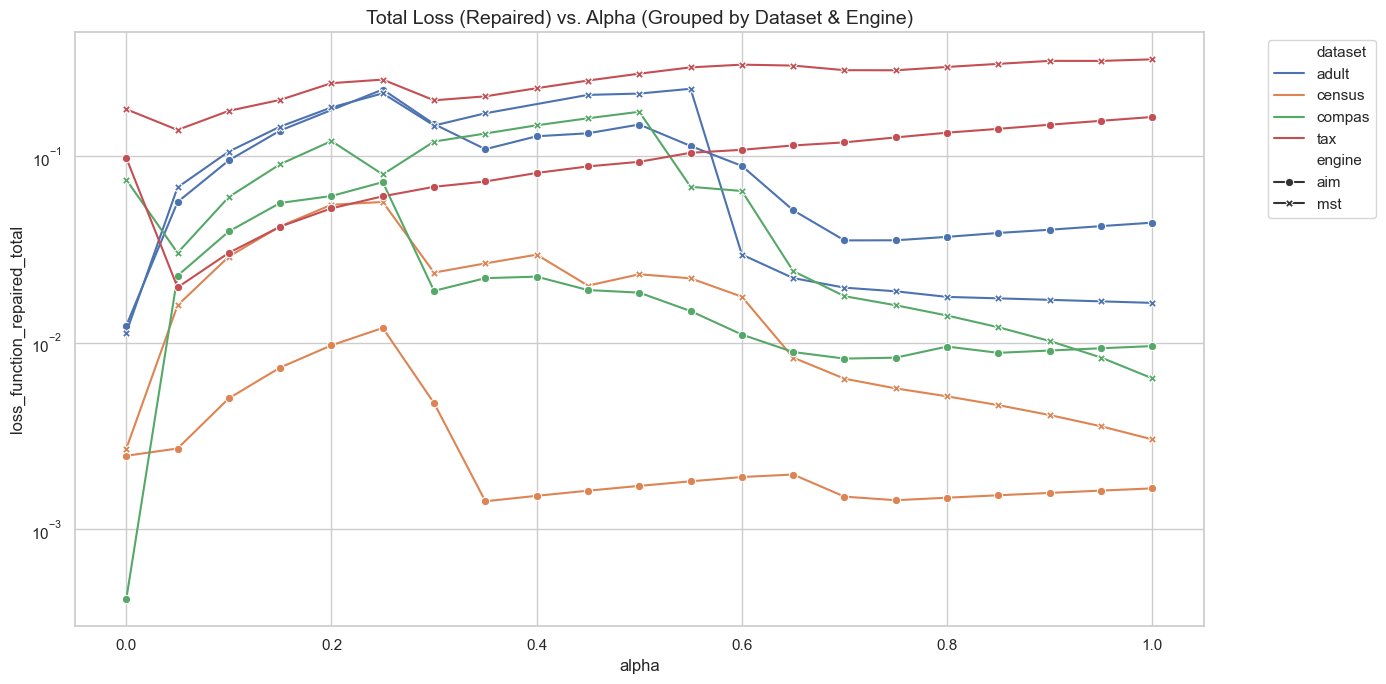

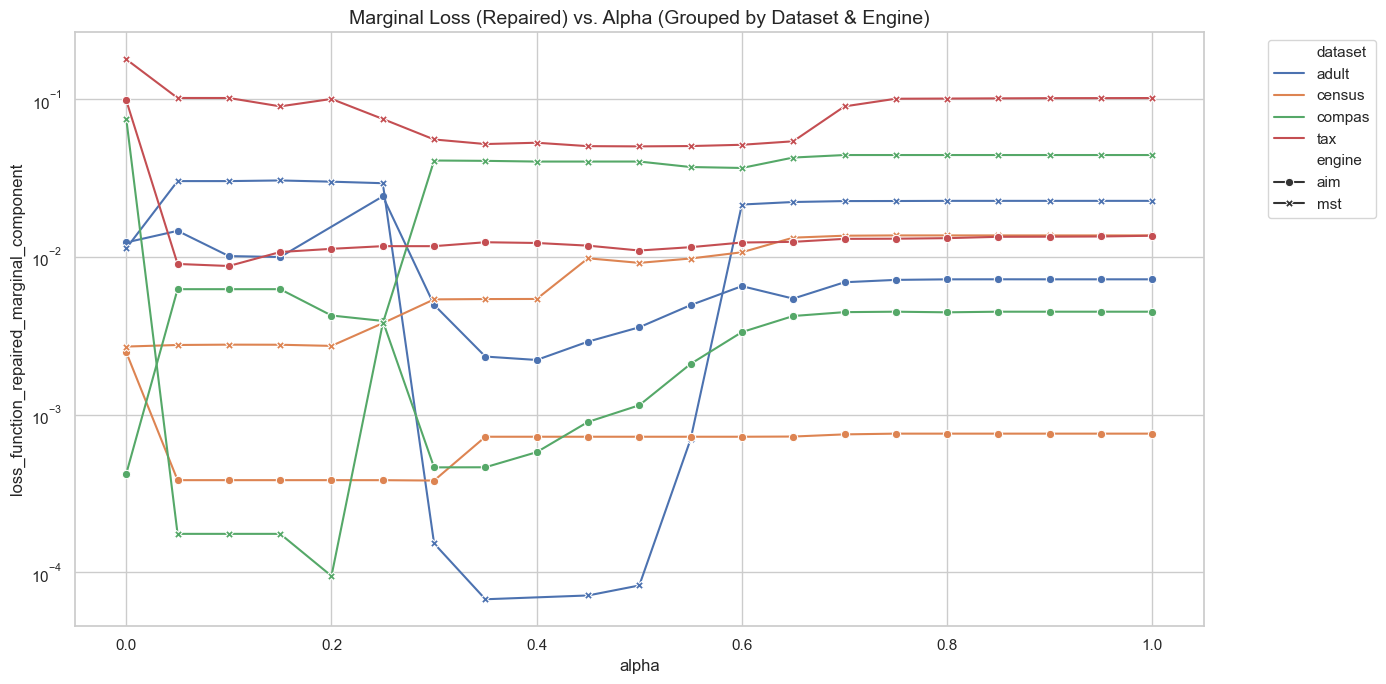

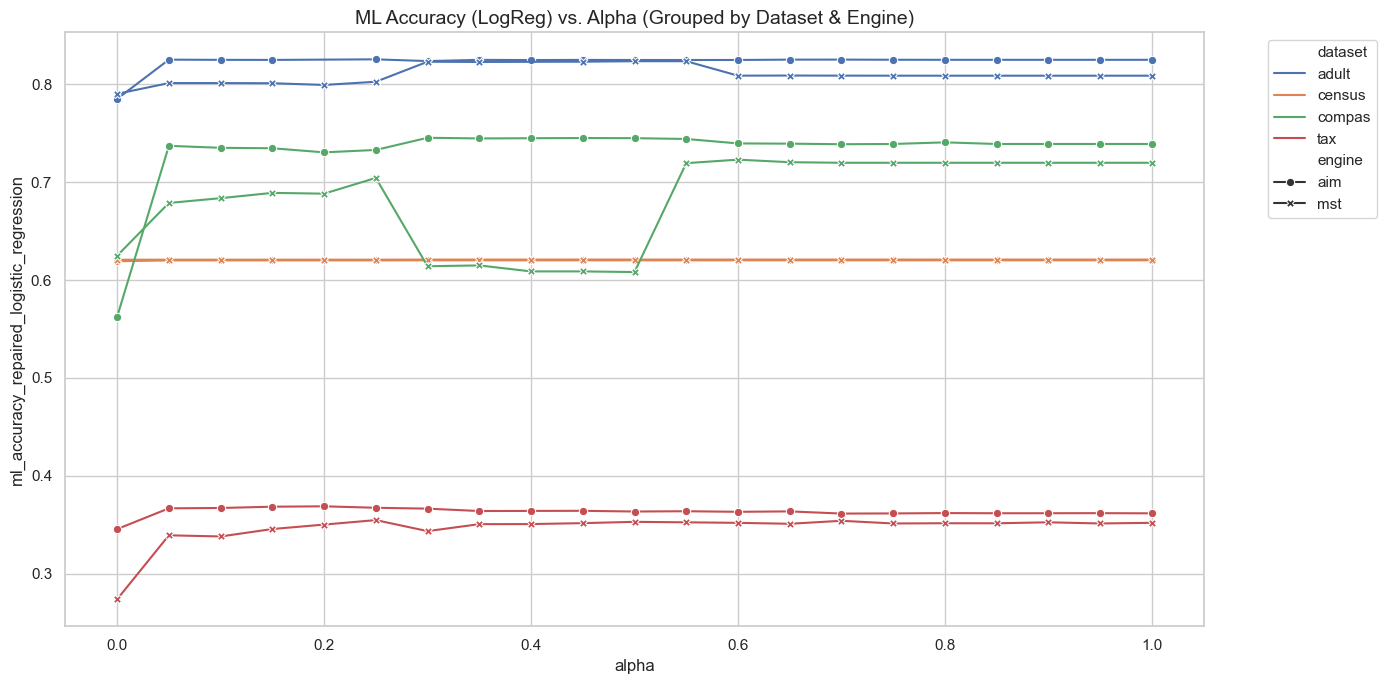

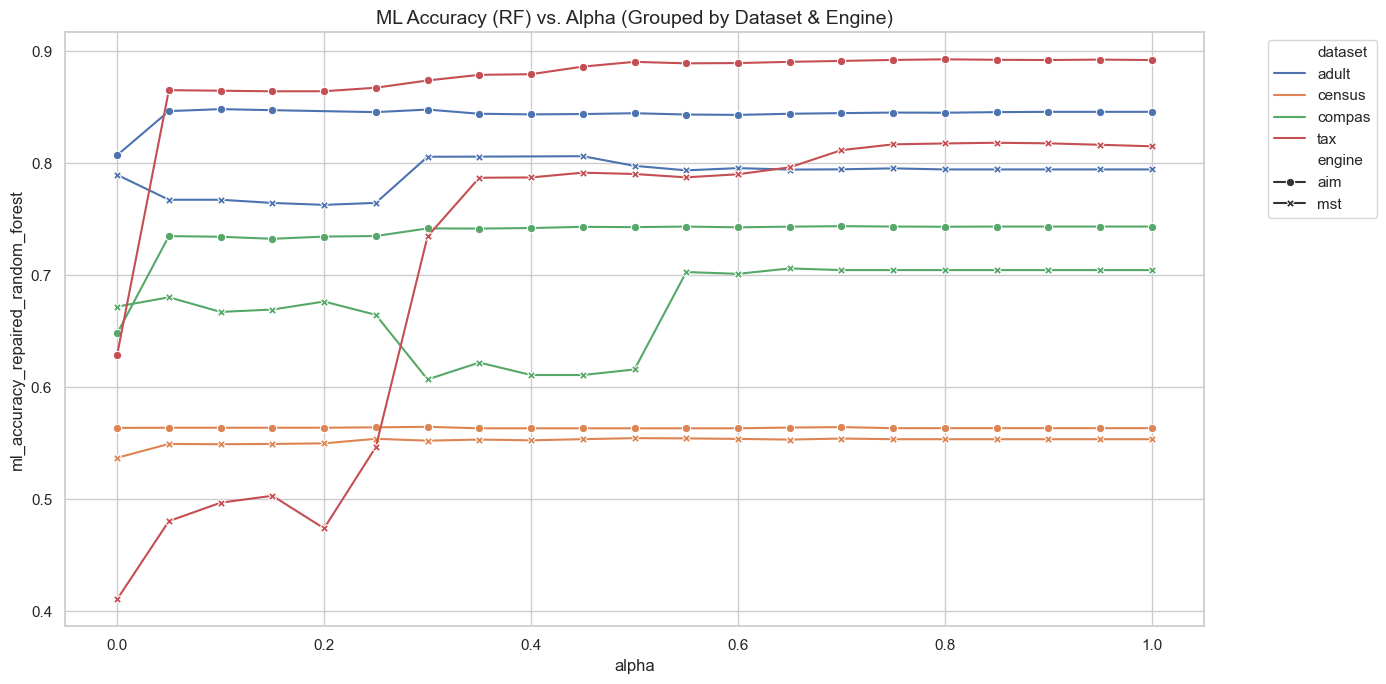

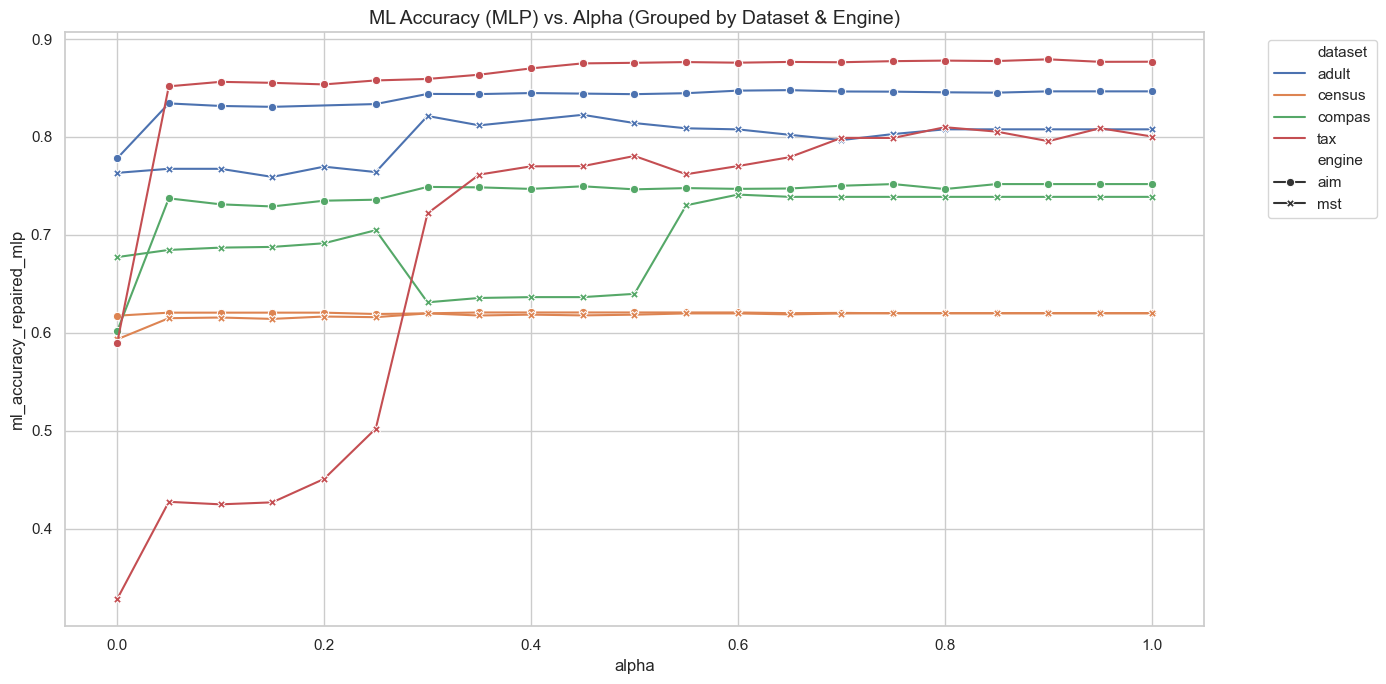

In [25]:
alpha_df = df[df['experiment_name'].str.contains('alpha_v4')].copy()

for m_col, m_title in metrics.items():
    plt.figure(figsize=(14, 7))
    # Using style for engine and hue for dataset. 
    # If we have multiple epsilons in alpha sweep, we could use size or alpha transparency, 
    # but here we mainly vary alpha.
    sns.lineplot(data=alpha_df, x='alpha', y=m_col, hue='dataset', style='engine', markers=True, dashes=False)
    plt.title(f"{m_title} vs. Alpha (Grouped by Dataset & Engine)", fontsize=14)
    if any(s in m_col for s in ['runtime', 'error', 'loss']):
        plt.yscale('log')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 2. Epsilon Sweep Analysis
Impact of the privacy budget `epsilon` on repair performance (Fixed Alpha=0.5).

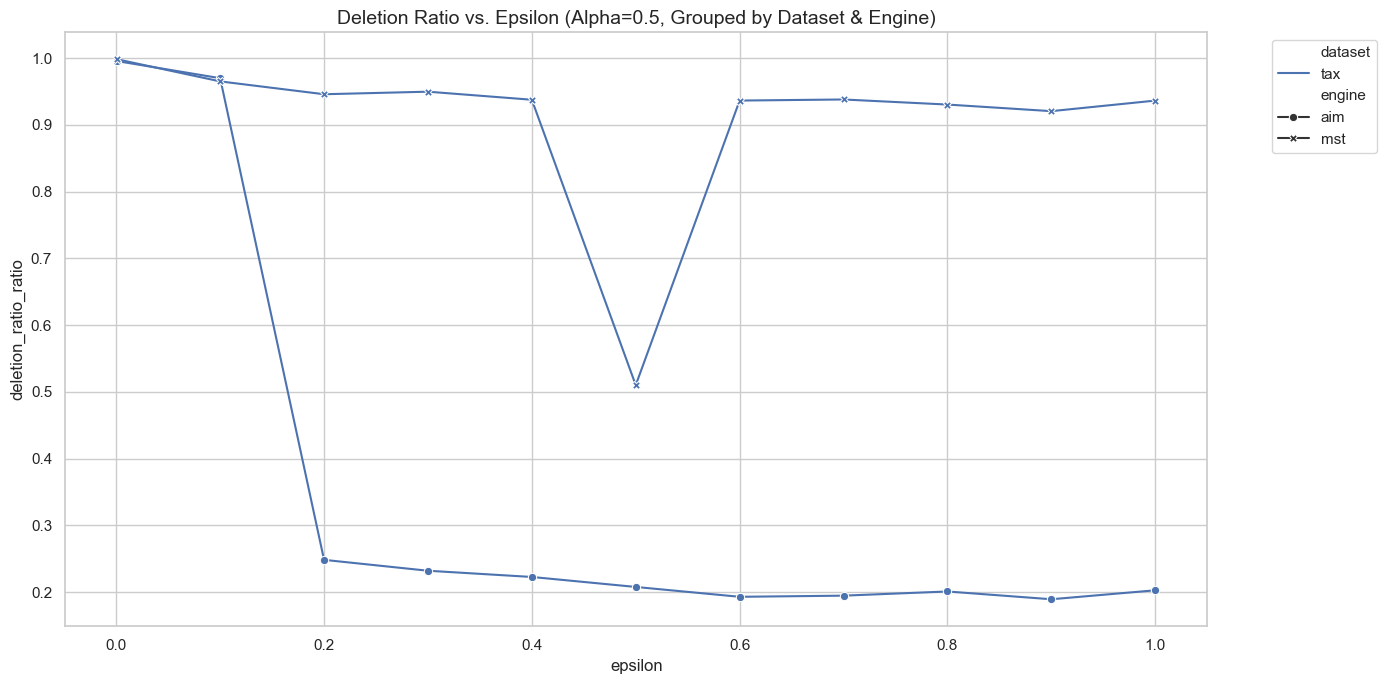

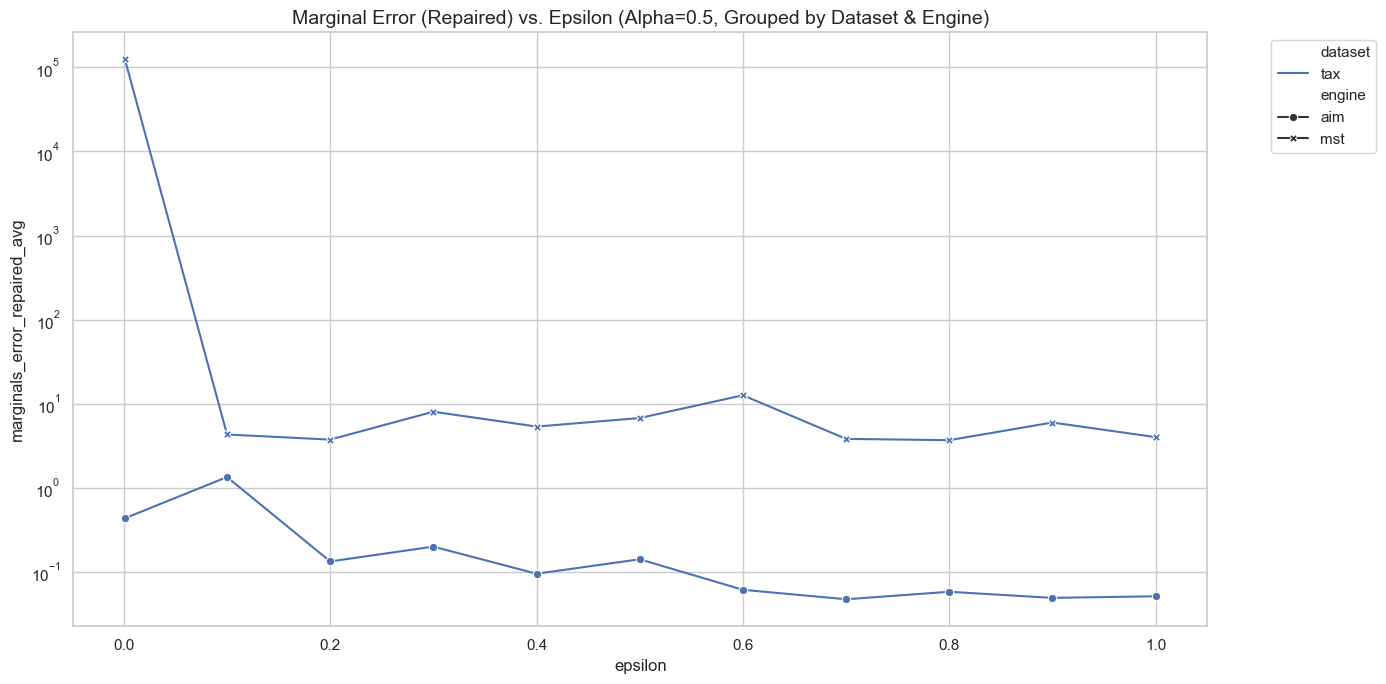

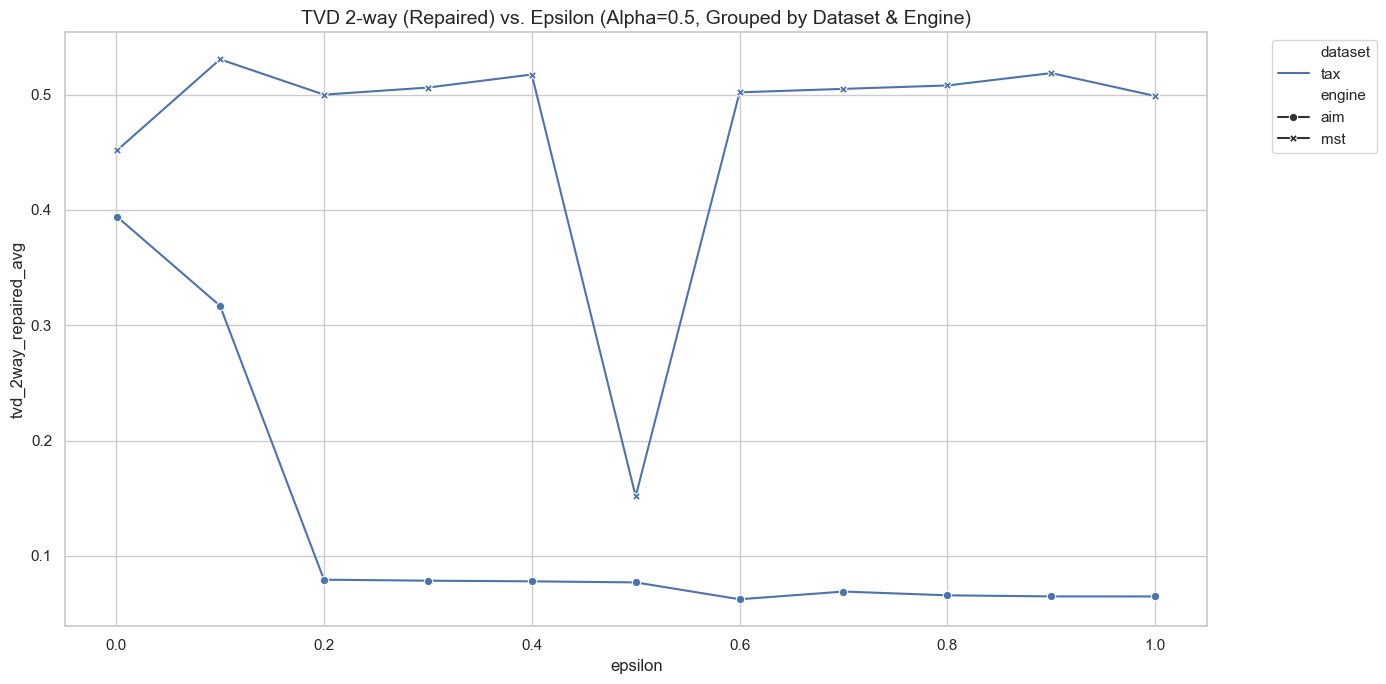

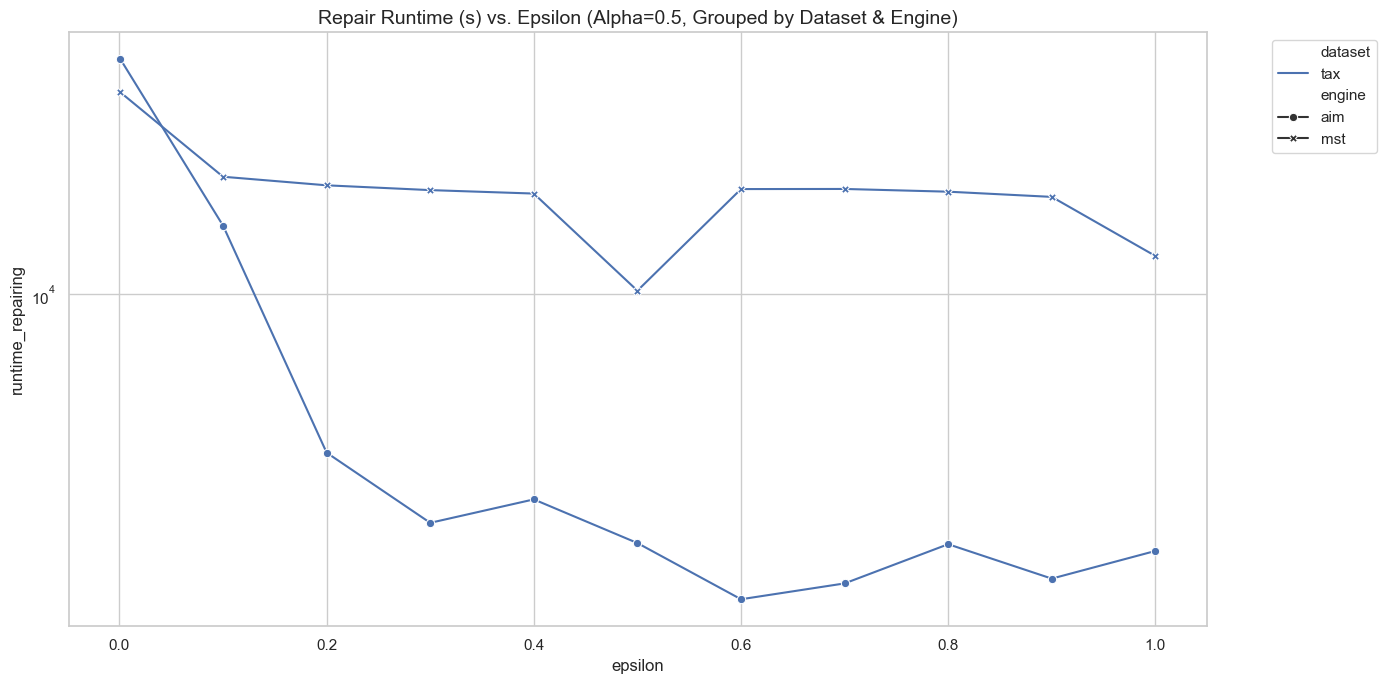

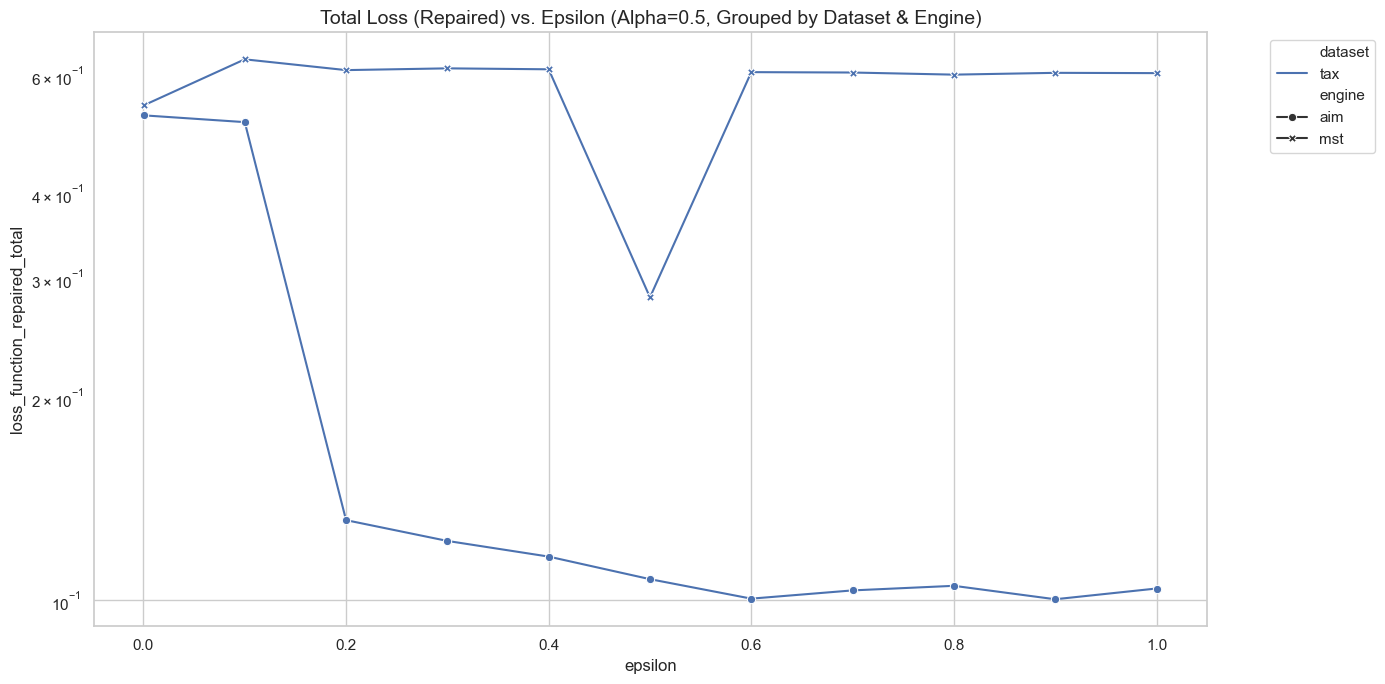

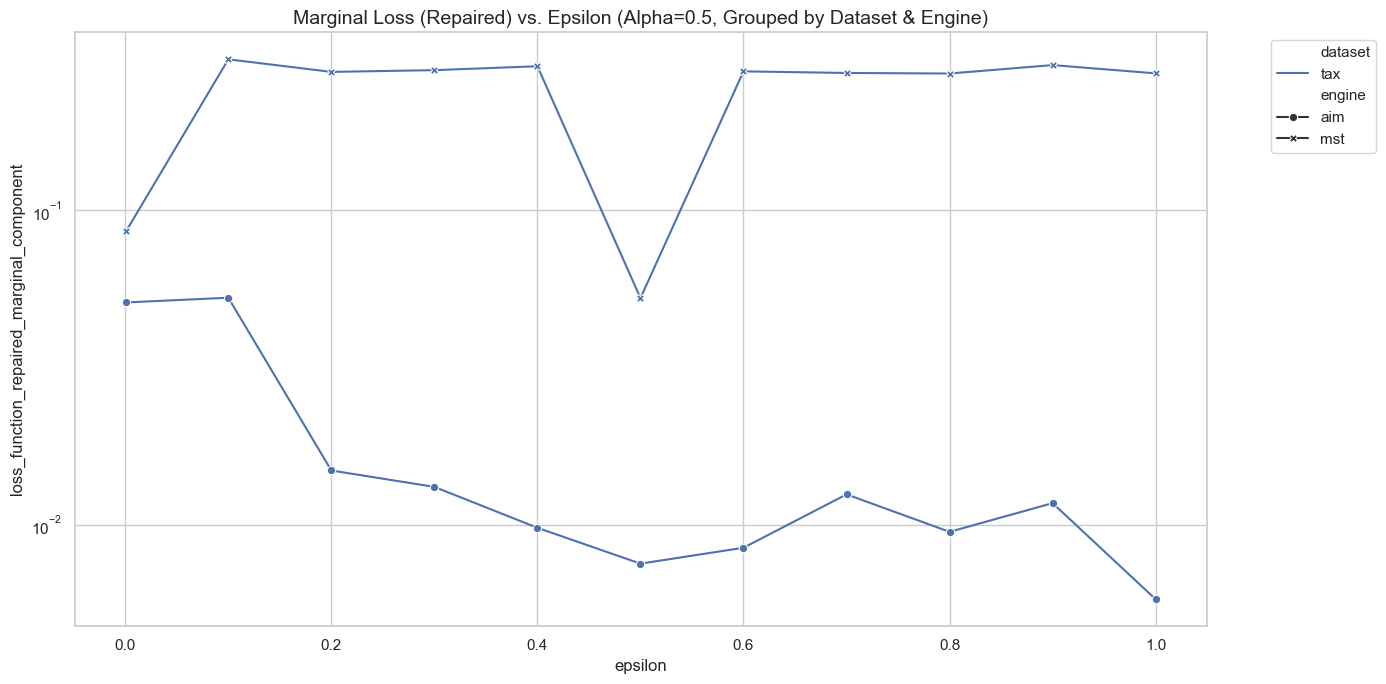

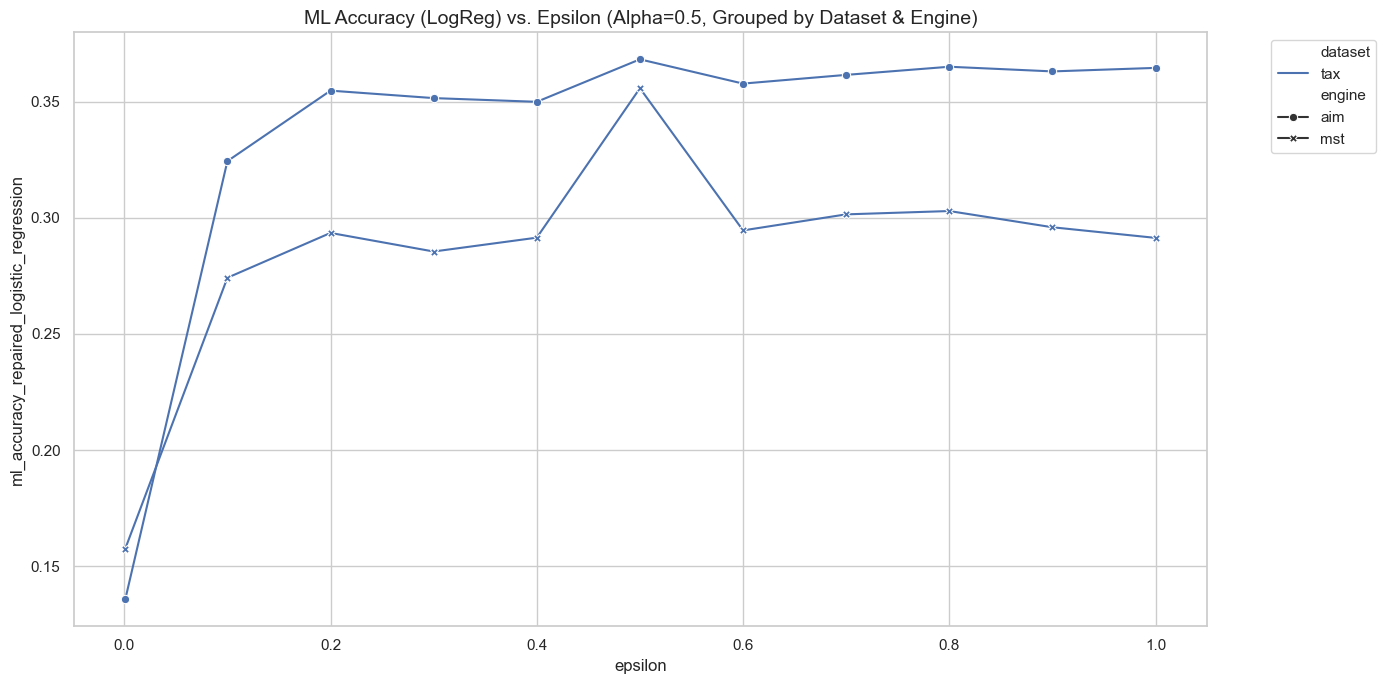

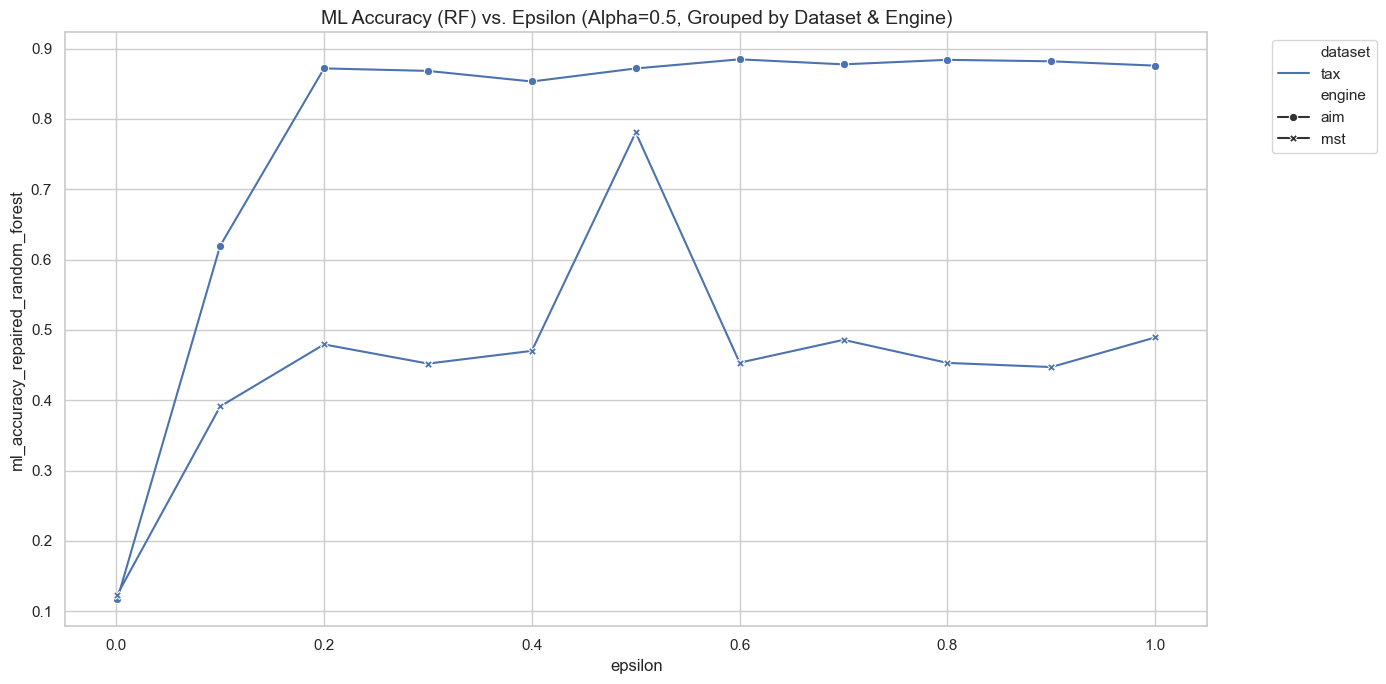

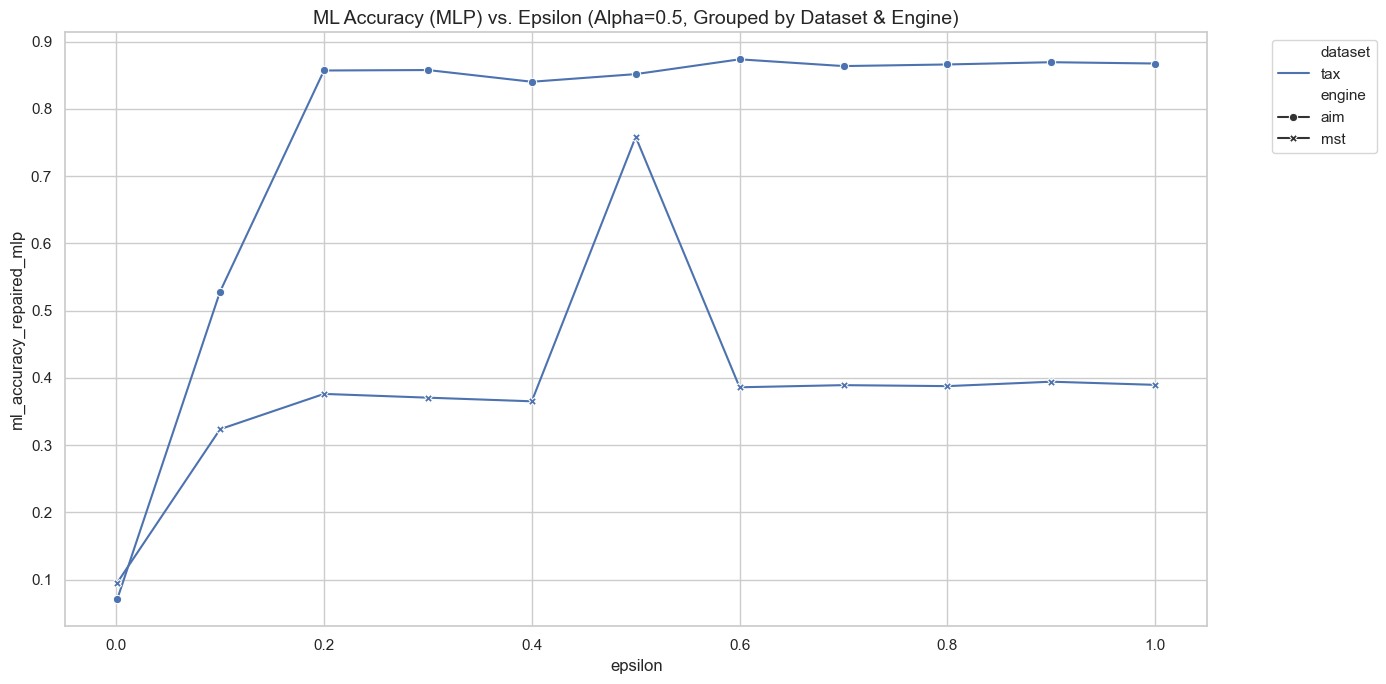

In [26]:
eps_df = df[df['experiment_name'].str.contains('eps_v4')].copy()
eps_df = eps_df.sort_values('epsilon')

for m_col, m_title in metrics.items():
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=eps_df, x='epsilon', y=m_col, hue='dataset', style='engine', markers=True, dashes=False)
    plt.title(f"{m_title} vs. Epsilon (Alpha=0.5, Grouped by Dataset & Engine)", fontsize=14)
    if any(s in m_col for s in ['runtime', 'error', 'loss']):
        plt.yscale('log')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 3. Comparative Metrics (Repaired vs Synthetic)
Comparing quality metrics before and after repair across the Alpha sweep.

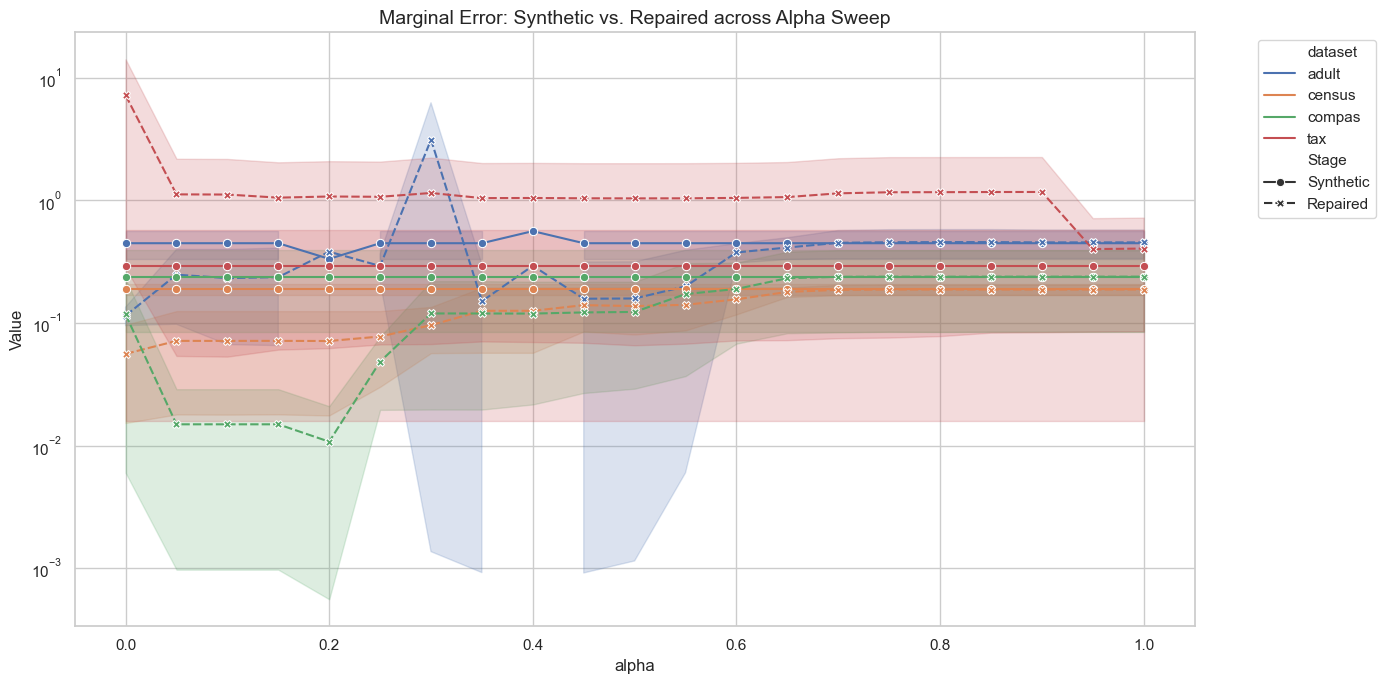

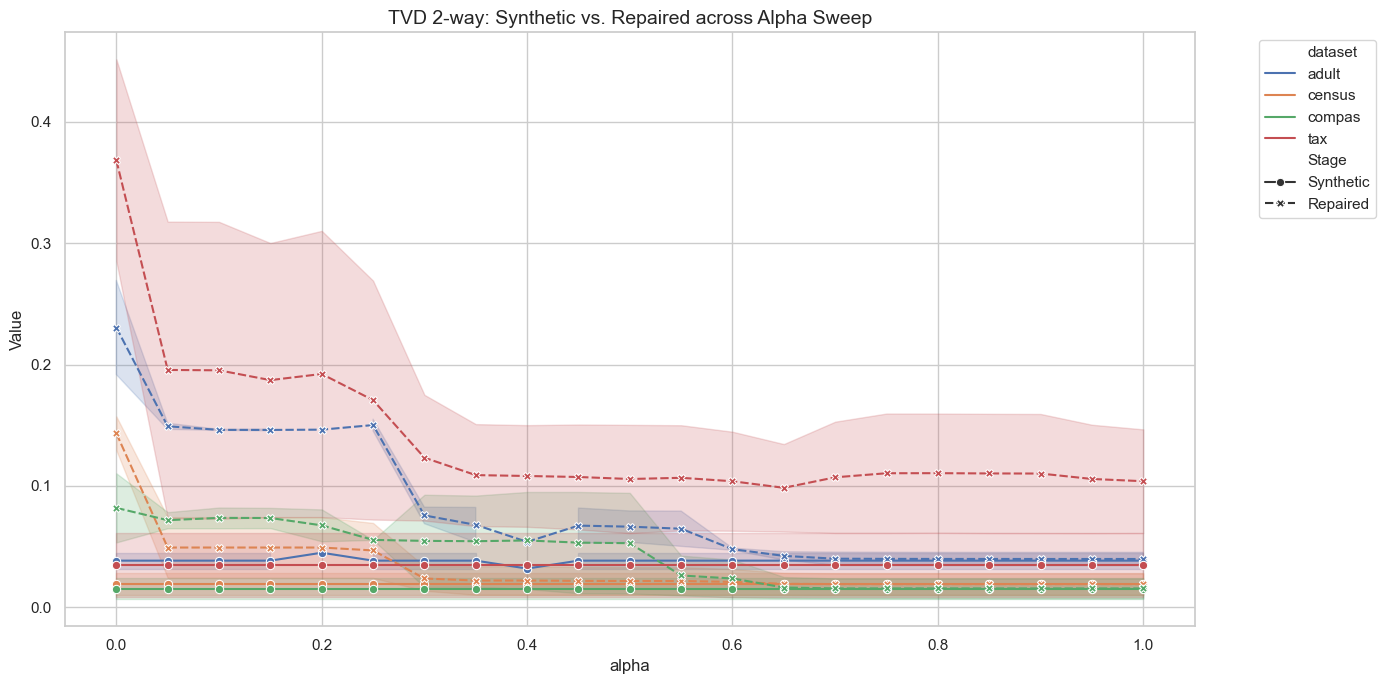

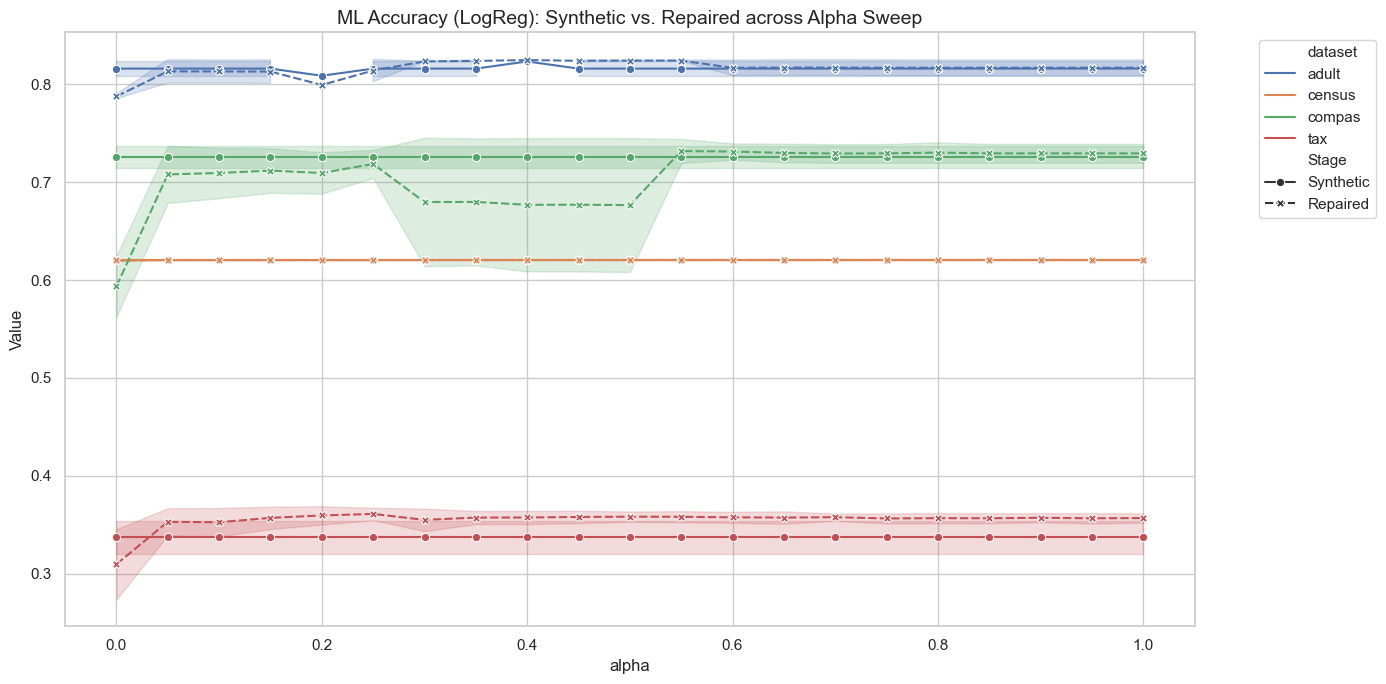

In [27]:
compare_metrics = [
    ('marginals_error_synthetic_avg', 'marginals_error_repaired_avg', 'Marginal Error'),
    ('tvd_2way_synthetic_avg', 'tvd_2way_repaired_avg', 'TVD 2-way'),
    ('ml_accuracy_synthetic_logistic_regression', 'ml_accuracy_repaired_logistic_regression', 'ML Accuracy (LogReg)')
]

for syn_col, rep_col, label in compare_metrics:
    plt.figure(figsize=(14, 7))
    # Melting for easier plotting of 'Before' vs 'After'
    melted = alpha_df.melt(id_vars=['alpha', 'dataset', 'engine'], value_vars=[syn_col, rep_col], 
                          var_name='Stage', value_name='Value')
    melted['Stage'] = melted['Stage'].apply(lambda x: 'Synthetic' if 'synthetic' in x else 'Repaired')
    
    sns.lineplot(data=melted, x='alpha', y='Value', hue='dataset', style='Stage', markers=True)
    plt.title(f"{label}: Synthetic vs. Repaired across Alpha Sweep", fontsize=14)
    if 'Error' in label:
        plt.yscale('log')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()